In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [34]:
df= pd.read_csv("/content/netflix_customer_churn.csv")
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [35]:
df.tail()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
4995,44f3ba44-b95d-4e50-a786-bac4d06f4a43,19,Female,Basic,49.17,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama
4996,18779bcb-ba2b-41da-b751-e70b812061ec,67,Female,Basic,9.24,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary
4997,3f32e8c5-615b-4a3b-a864-db2688f7834f,66,Male,Standard,16.55,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action
4998,7b0ad82d-6571-430e-90f4-906259e0e89c,59,Female,Basic,9.12,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi
4999,82aeef39-ddb0-40ad-bae1-5c436e0cf042,57,Male,Basic,1.62,17,Africa,Mobile,8.99,1,Crypto,2,0.09,Action


In [36]:
df.isna().sum()

,0
customer_id,0
age,0
gender,0
subscription_type,0
watch_hours,0
last_login_days,0
region,0
device,0
monthly_fee,0
churned,0


In [37]:
df.duplicated().sum()


np.int64(0)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [39]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [40]:
df["churned"].value_counts(normalize=True).mul(100).round(2)

,proportion
churned,
1,50.3
0,49.7


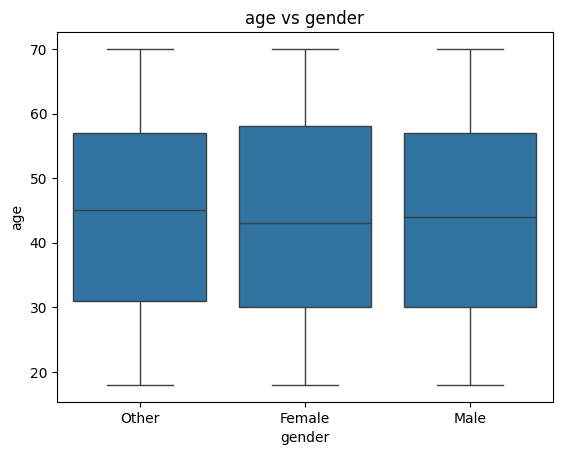

In [41]:
sns.boxplot(y=df['age'],x=df['gender'])
plt.title("age vs gender")
plt.show()

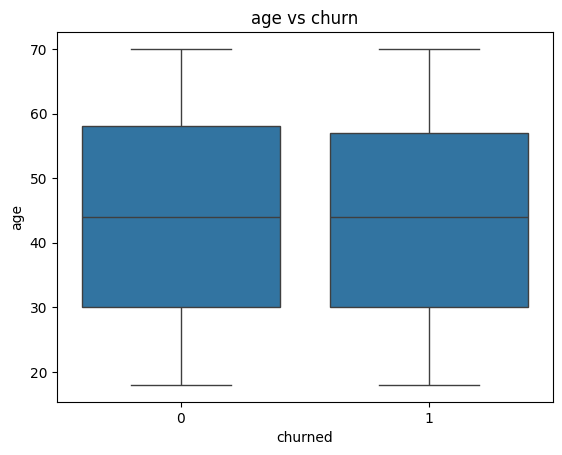

In [42]:
sns.boxplot(x=df['churned'],y=df['age'])
plt.title("age vs churn")
plt.show()

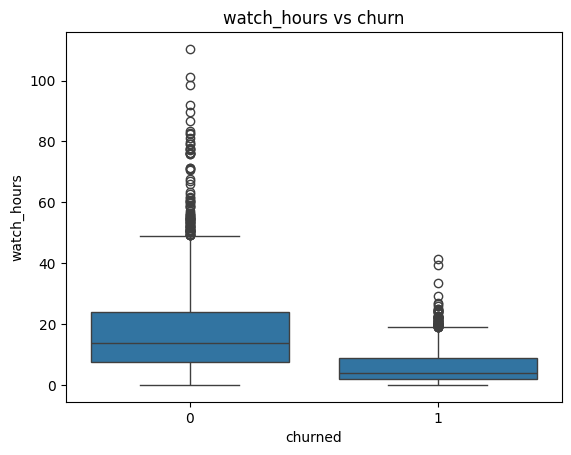

In [43]:
sns.boxplot(x=df['churned'],y=df['watch_hours'])
plt.title("watch_hours vs churn")
plt.show()

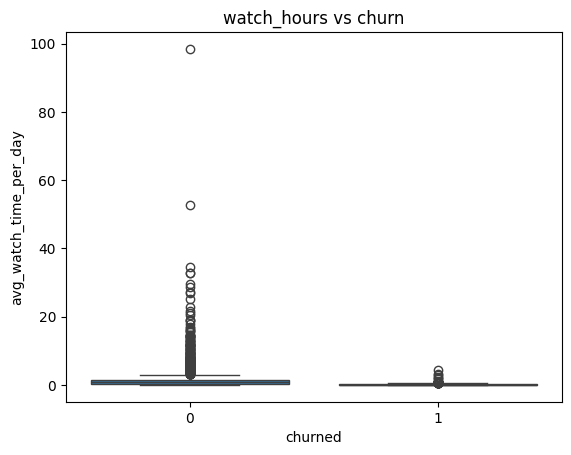

In [44]:
sns.boxplot(x=df['churned'],y=df['avg_watch_time_per_day'])
plt.title("watch_hours vs churn")
plt.show()

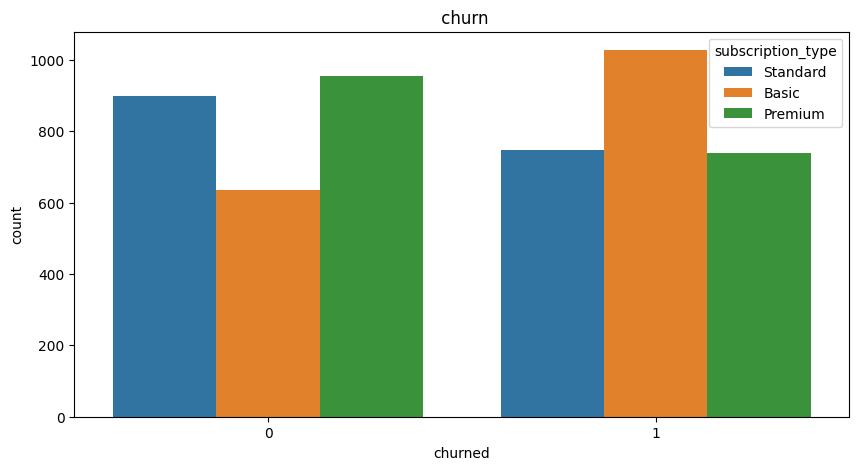

In [64]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['churned'],hue=df['subscription_type'])
plt.title("churn")
plt.show()

In [46]:
pd.crosstab(df["region"],df["churned"],normalize="index").round(3)

churned,0,1
region,,
Africa,0.517,0.483
Asia,0.493,0.507
Europe,0.483,0.517
North America,0.505,0.495
Oceania,0.499,0.501
South America,0.486,0.514


In [47]:
pd.crosstab(df["payment_method"],df["churned"],normalize="index").round(3)

churned,0,1
payment_method,,
Credit Card,0.564,0.436
Crypto,0.403,0.597
Debit Card,0.563,0.437
Gift Card,0.422,0.578
PayPal,0.529,0.471


In [48]:
numeric_cols = [
    "age",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day"
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
watch_hours: 238 outliers
last_login_days: 0 outliers
monthly_fee: 0 outliers
number_of_profiles: 0 outliers
avg_watch_time_per_day: 549 outliers


In [49]:
for col in ["watch_hours", "avg_watch_time_per_day"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col}")
    print("Lower limit:", lower)
    print("Upper limit:", upper)
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Outlier count:", len(outliers))


watch_hours
Lower limit: -15.70125
Upper limit: 35.06875
Minimum: 0.01
Maximum: 110.4
Outlier count: 238

avg_watch_time_per_day
Lower limit: -0.805
Upper limit: 1.635
Minimum: 0.0
Maximum: 98.42
Outlier count: 549


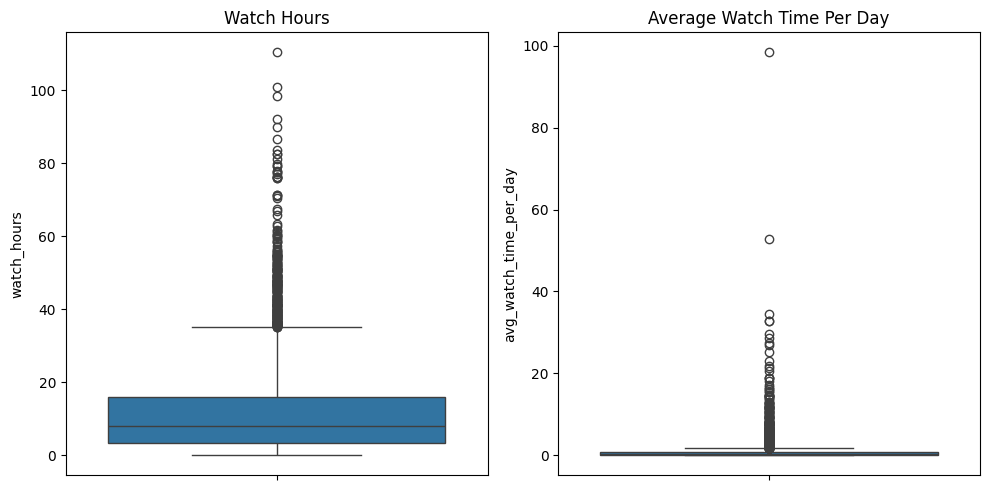

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(y=df["watch_hours"], ax=axes[0])
axes[0].set_title("Watch Hours")

sns.boxplot(y=df["avg_watch_time_per_day"], ax=axes[1])
axes[1].set_title("Average Watch Time Per Day")

plt.tight_layout()
plt.show()

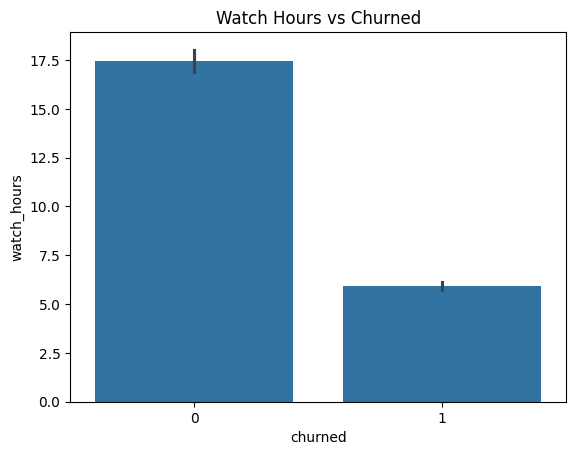

In [51]:
sns.barplot(x=df["churned"], y=df["watch_hours"])
plt.title("Watch Hours vs Churned")
plt.show()

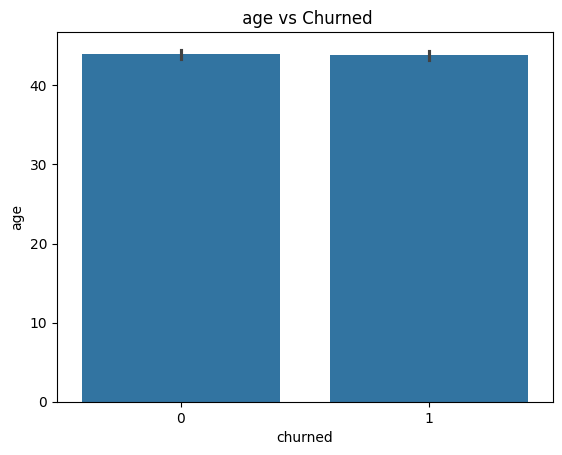

In [52]:
sns.barplot(x=df["churned"], y=df["age"])
plt.title(" age vs Churned")
plt.show()

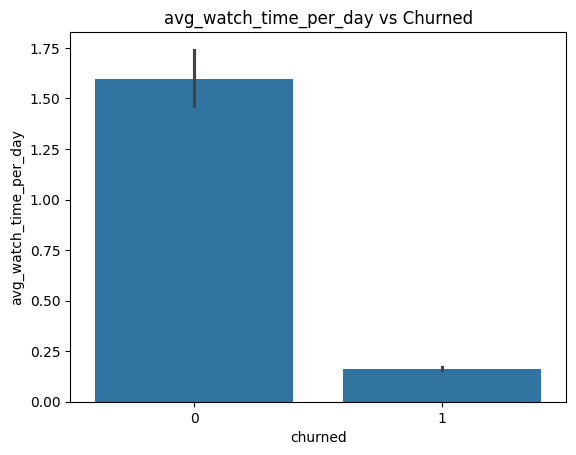

In [53]:
sns.barplot(x=df["churned"], y=df["avg_watch_time_per_day"])
plt.title("avg_watch_time_per_day vs Churned")
plt.show()

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

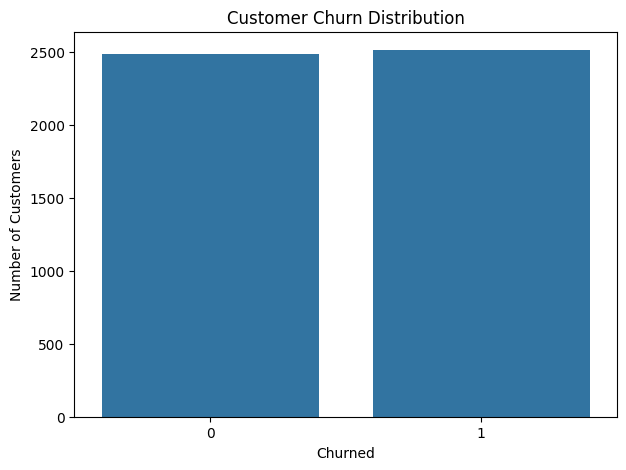

In [55]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="churned"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")

plt.show()

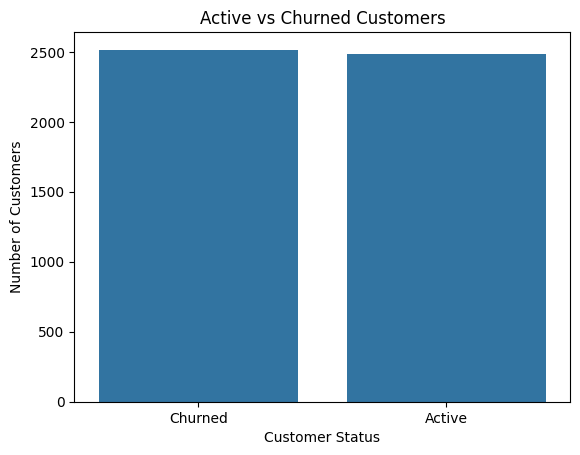

In [56]:
df["churn_label"] = df["churned"].map({
    0: "Active",
    1: "Churned"
})

sns.countplot(
    data=df,
    x="churn_label"
)

plt.title("Active vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

Text(0, 0.5, 'Watch Hours')

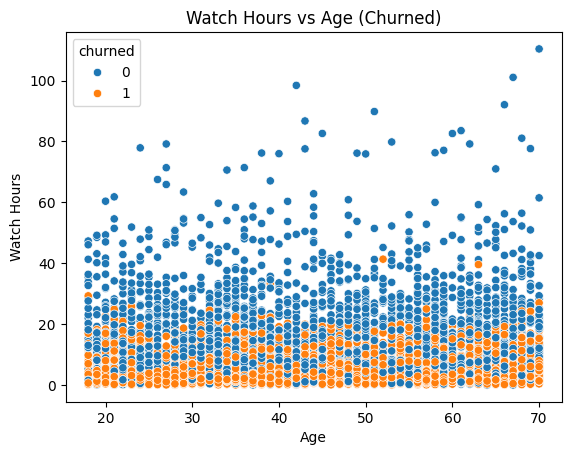

In [66]:
sns.scatterplot(
    data=df,
    x="age",
    y="watch_hours",
    hue="churned"
)

plt.title("Watch Hours vs Age (Churned)")
plt.xlabel("Age")
plt.ylabel("Watch Hours")

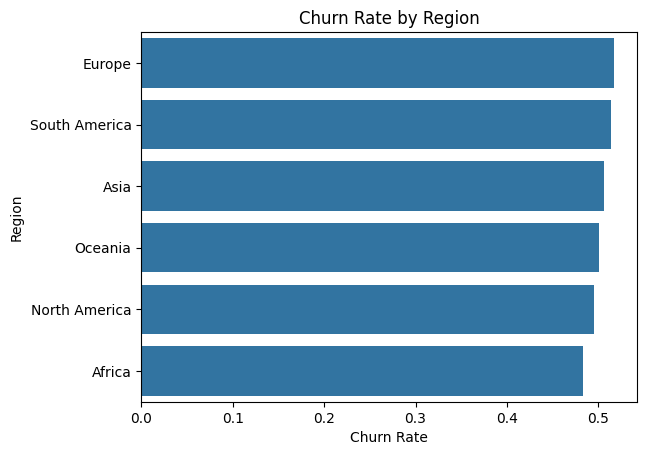

In [58]:
region_churn = (
    df.groupby("region")["churned"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=region_churn.values,
    y=region_churn.index
)

plt.title("Churn Rate by Region")
plt.xlabel("Churn Rate")
plt.ylabel("Region")

plt.show()

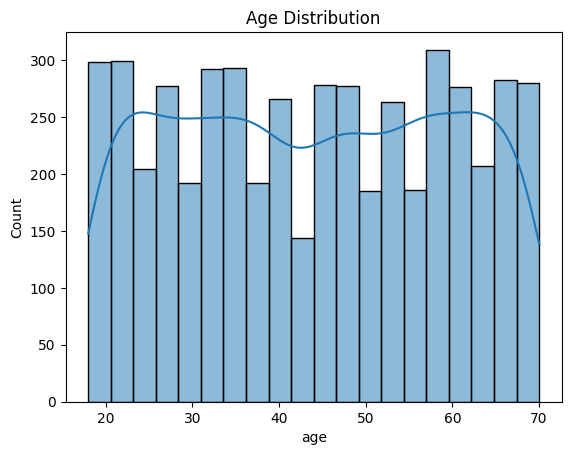

In [59]:
sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.show()

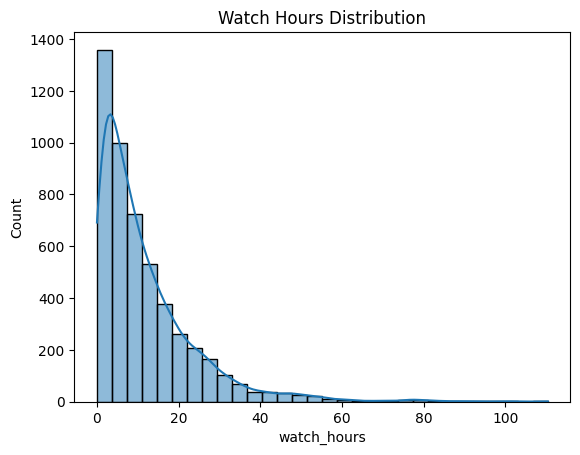

In [60]:
sns.histplot(
    data=df,
    x="watch_hours",
    bins=30,
    kde=True
)

plt.title("Watch Hours Distribution")
plt.show()

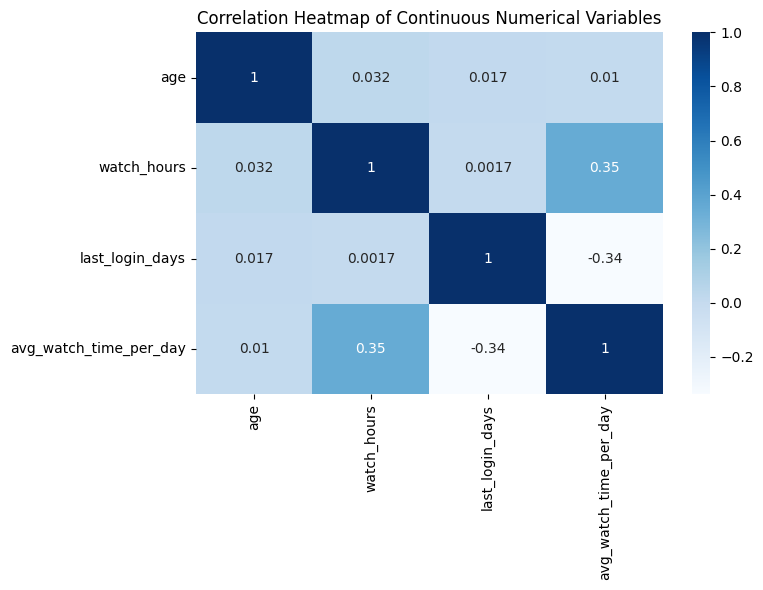

In [69]:
plt.figure(figsize=(8,6))
heatmap = df[["age","watch_hours","last_login_days","avg_watch_time_per_day"]].corr()
sns.heatmap(heatmap, annot=True, cmap=sns.color_palette("Blues", as_cmap=True))
plt.title("Correlation Heatmap of Continuous Numerical Variables")
plt.tight_layout()
plt.show()

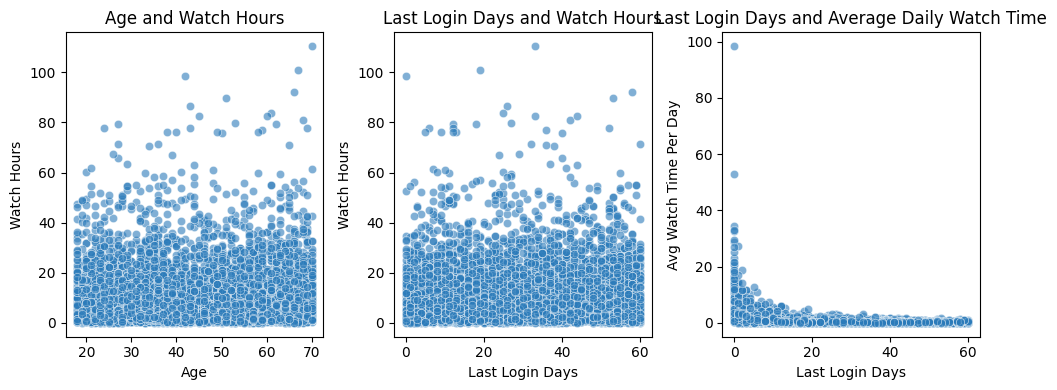

In [73]:
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
sns.scatterplot(data=df, x="age", y="watch_hours", color=sns.color_palette("Blues")[4], alpha=0.6)
plt.xlabel("Age")
plt.ylabel("Watch Hours")
plt.title("Age and Watch Hours")
plt.subplot(1,3,2)
sns.scatterplot(data=df, x="last_login_days", y="watch_hours", color=sns.color_palette("Blues")[4], alpha=0.6)
plt.xlabel("Last Login Days")
plt.ylabel("Watch Hours")
plt.title("Last Login Days and Watch Hours")
plt.subplot(1,3,3)
sns.scatterplot(data=df, x="last_login_days", y="avg_watch_time_per_day", color=sns.color_palette("Blues")[4], alpha=0.6)
plt.xlabel("Last Login Days")
plt.ylabel("Avg Watch Time Per Day")
plt.title("Last Login Days and Average Daily Watch Time")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1804/4178834067.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="churned", palette="Blues", edgecolor="black")


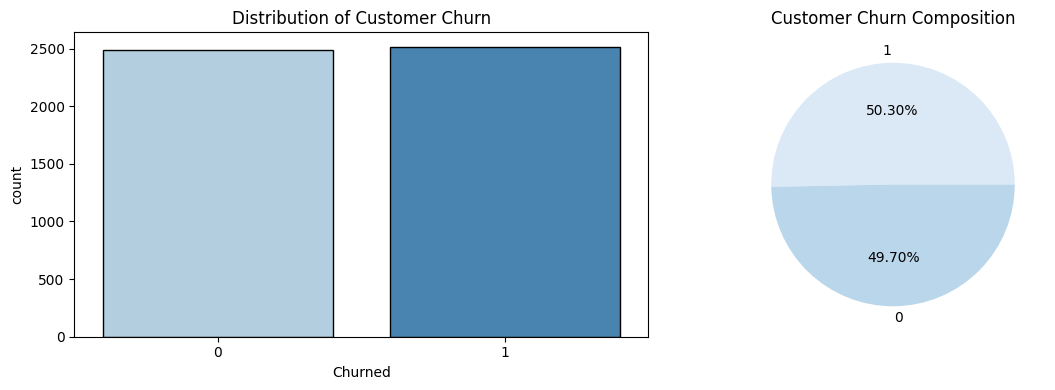

In [75]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.countplot(data=df, x="churned", palette="Blues", edgecolor="black")
plt.xlabel("Churned")
plt.ylabel("count")
plt.title("Distribution of Customer Churn")
plt.subplot(1,2,2)
plt.pie(df["churned"].value_counts(), labels=df["churned"].value_counts().index, autopct="%0.2f%%", colors=sns.color_palette("Blues"))
plt.title("Customer Churn Composition")
plt.tight_layout()
plt.show()

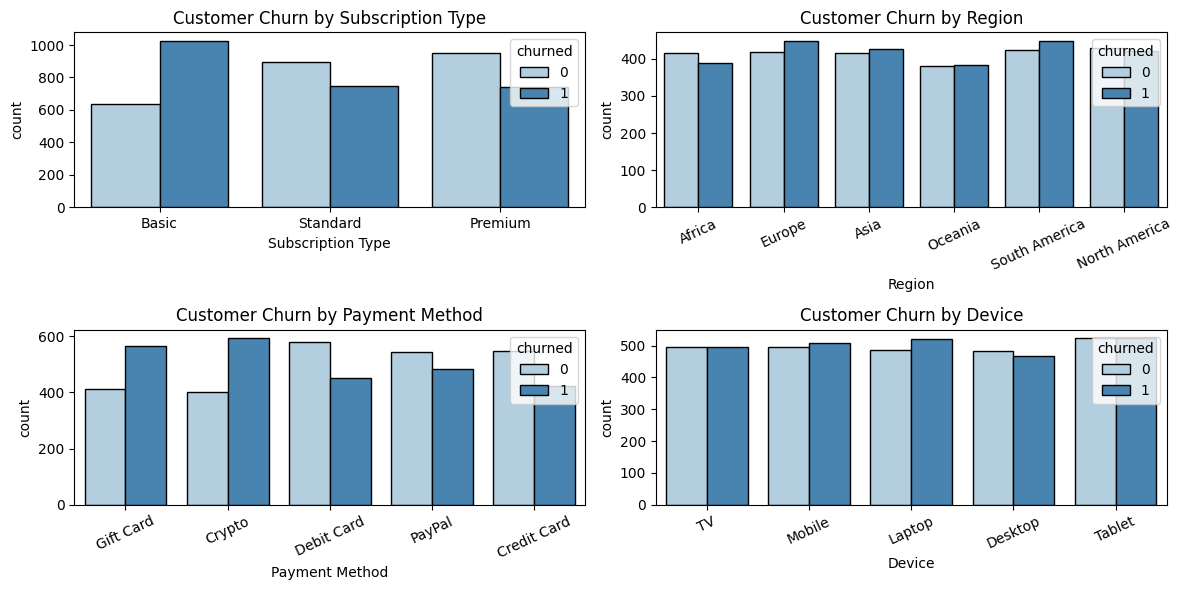

In [78]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.countplot(data=df, x="subscription_type", hue="churned", palette="Blues", edgecolor="black")
plt.xlabel("Subscription Type")
plt.ylabel("count")
plt.title("Customer Churn by Subscription Type")
plt.subplot(2,2,2)
sns.countplot(data=df, x="region", hue="churned", palette="Blues", edgecolor="black")
plt.xlabel("Region")
plt.ylabel("count")
plt.title("Customer Churn by Region")
plt.xticks(rotation=25)
plt.subplot(2,2,3)
sns.countplot(data=df, x="payment_method", hue="churned", palette="Blues", edgecolor="black")
plt.xlabel("Payment Method")
plt.ylabel("count")
plt.title("Customer Churn by Payment Method")
plt.xticks(rotation=25)
plt.subplot(2,2,4)
sns.countplot(data=df, x="device", hue="churned", palette="Blues", edgecolor="black")
plt.xlabel("Device")
plt.ylabel("count")
plt.title("Customer Churn by Device")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


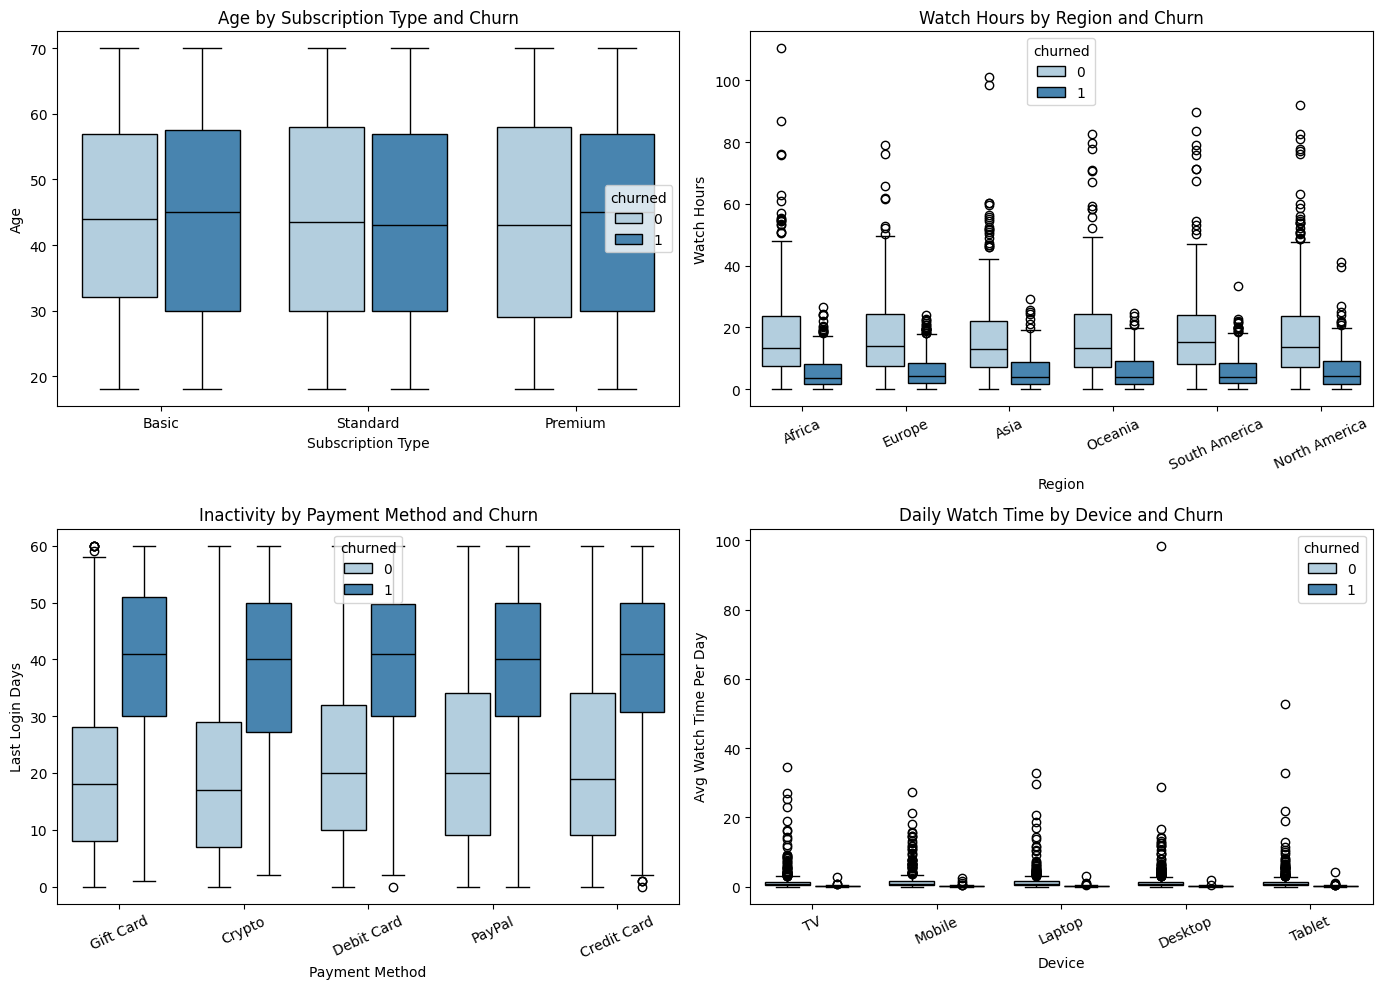

In [83]:
plt.figure(figsize=(14,10))
plt.subplot(2,2,1)
sns.boxplot(data=df, x="subscription_type", y="age", hue="churned", gap=0.1, palette="Blues", linecolor="black")
plt.xlabel("Subscription Type")
plt.ylabel("Age")
plt.title("Age by Subscription Type and Churn")
plt.subplot(2,2,2)
sns.boxplot(data=df, x="region", y="watch_hours", hue="churned", gap=0.1, palette="Blues", linecolor="black")
plt.xlabel("Region")
plt.ylabel("Watch Hours")
plt.title("Watch Hours by Region and Churn")
plt.xticks(rotation=25)
plt.subplot(2,2,3)
sns.boxplot(data=df, x="payment_method", y="last_login_days", hue="churned", gap=0.1, palette="Blues", linecolor="black")
plt.xlabel("Payment Method")
plt.ylabel("Last Login Days")
plt.title("Inactivity by Payment Method and Churn")
plt.xticks(rotation=25)
plt.subplot(2,2,4)
sns.boxplot(data=df, x="device", y="avg_watch_time_per_day", hue="churned", gap=0.1, palette="Blues", linecolor="black")
plt.xlabel("Device")
plt.ylabel("Avg Watch Time Per Day")
plt.title("Daily Watch Time by Device and Churn")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()